<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Thesis/blob/main/A_Hybrid_CNN_and_EfficientNetB3_Attention_Based_Transfer_Learning_Framework_for_Multi_Class_Skin_Lesion_Classification_Using_the_PAD_UFES_20_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize

In [ ]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path = "/content/drive/MyDrive/SkinCancer_Split/test"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print(train_generator.class_indices)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [ ]:
input_layer = Input(shape=(224,224,3))

# CNN branch
x = Conv2D(32,3,activation='relu',padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(64,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(128,3,activation='relu',padding='same')(x)
x = BatchNormalization()(x)

cnn_features = GlobalAveragePooling2D()(x)

# EfficientNetB3 branch
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

base_model.trainable = True

# Fine-tune last 80 layers
for layer in base_model.layers[:-80]:
    layer.trainable = False

y = base_model.output
y = GlobalAveragePooling2D()(y)

# Attention
attention = Dense(1536, activation='relu')(y)
attention = Dense(1536, activation='sigmoid')(attention)

attention_features = Multiply()([y, attention])

# Feature fusion
combined = Concatenate()(
    [cnn_features, attention_features]
)

# Classification head
z = Dense(512, activation='relu')(combined)
z = BatchNormalization()(z)

z = Dense(256, activation='relu')(z)
z = Dropout(0.5)(z)

output = Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'
)(z)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 16,586,741 (63.27 MB)

 Trainable params: 12,551,182 (47.88 MB)

 Non-trainable params: 4,035,559 (15.39 MB)

In [ ]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        "best_Hybrid_CNN_EfficientNetB3_Attention_PADUFES20.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1868 - loss: 2.6023 
Epoch 1: val_accuracy improved from None to 0.35652, saving model to best_Hybrid_CNN_EfficientNetB3_Attention_PADUFES20.keras

Epoch 1: finished saving model to best_Hybrid_CNN_EfficientNetB3_Attention_PADUFES20.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 972s 16s/step - accuracy: 0.2018 - loss: 2.3518 - val_accuracy: 0.3565 - val_loss: 1.6808 - learning_rate: 5.0000e-05
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2567 - loss: 2.1335
Epoch 2: val_accuracy improved from 0.35652 to 0.39565, saving model to best_Hybrid_CNN_EfficientNetB3_Attention_PADUFES20.keras

Epoch 2: finished saving model to best_Hybrid_CNN_EfficientNetB3_Attention_PADUFES20.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 614s 10s/step - accuracy: 0.2748 - loss: 1.9286 - val_accuracy: 0.3957 - val_loss: 1.6395 - learning_rate: 5.0000e-05
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2878 - loss: 1.7149
Epoch 3: val_accurac

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.6652 - loss: 0.9662
Test Accuracy : 66.52%
Test Loss     : 0.9662


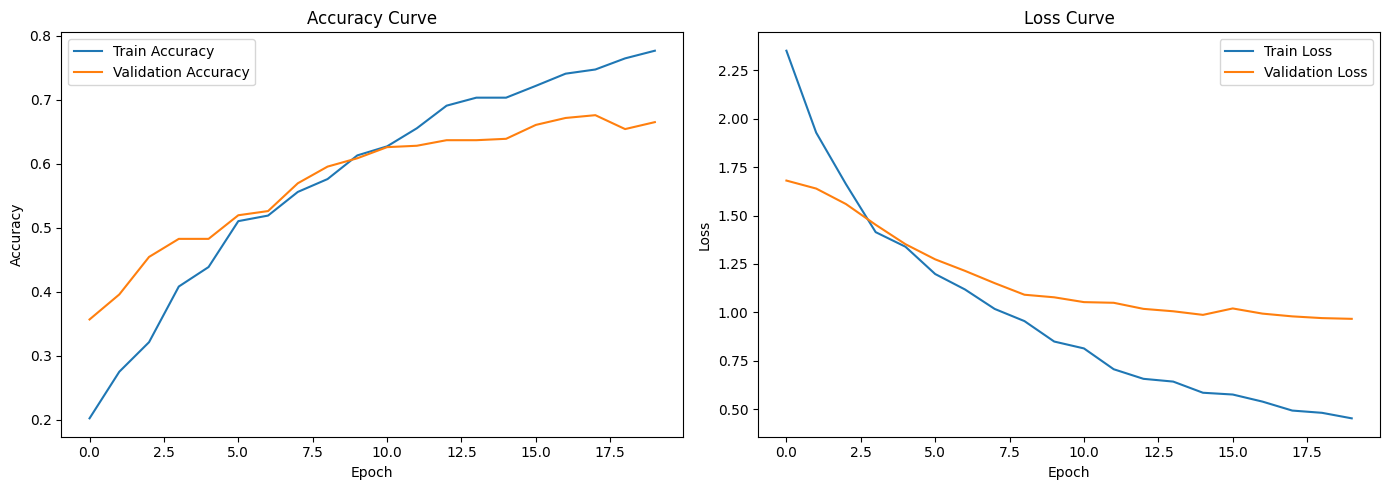

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob,axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

15/15 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step


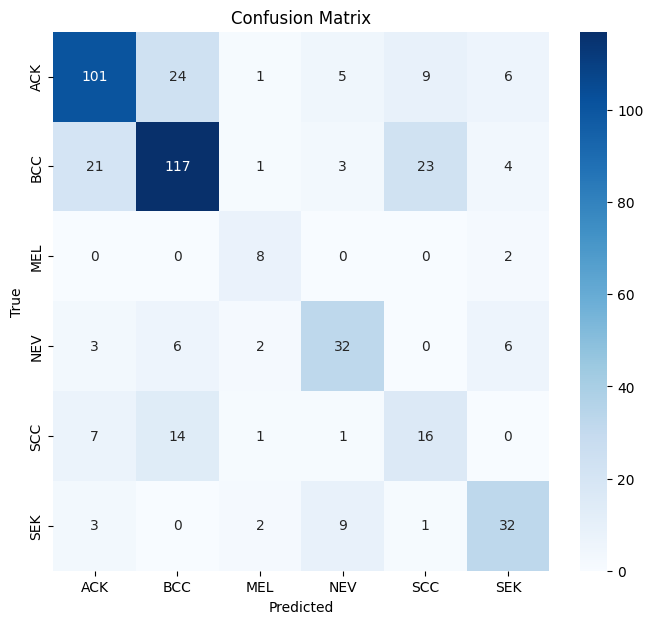

In [ ]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.75      0.69      0.72       146
         BCC       0.73      0.69      0.71       169
         MEL       0.53      0.80      0.64        10
         NEV       0.64      0.65      0.65        49
         SCC       0.33      0.41      0.36        39
         SEK       0.64      0.68      0.66        47

    accuracy                           0.67       460
   macro avg       0.60      0.65      0.62       460
weighted avg       0.68      0.67      0.67       460



In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :",round(precision*100,2),"%")
print("Recall    :",round(recall*100,2),"%")
print("F1 Score  :",round(f1*100,2),"%")

Precision : 67.73 %
Recall    : 66.52 %
F1 Score  : 66.97 %


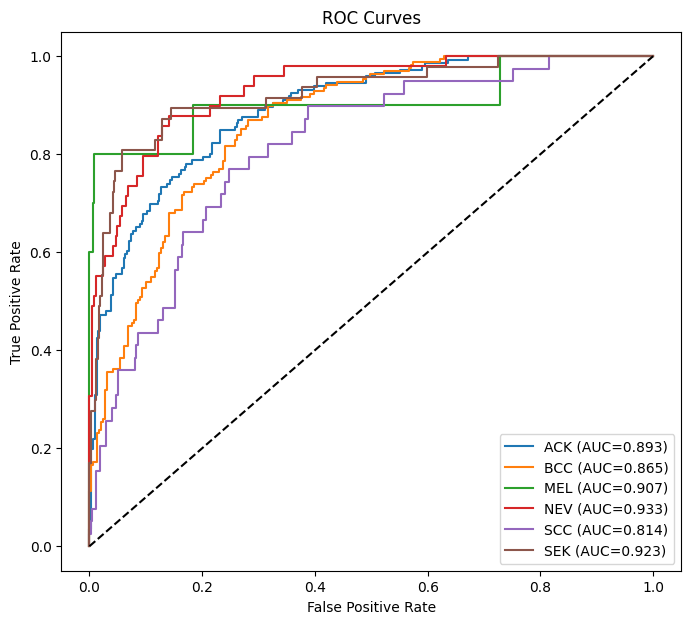

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,7))

roc_auc = {}

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc[i] = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc[i]:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
print("AUC Values")

for i in range(len(class_names)):
    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )

AUC Values
ACK : 0.893
BCC : 0.8646
MEL : 0.9071
NEV : 0.9329
SCC : 0.8136
SEK : 0.9233


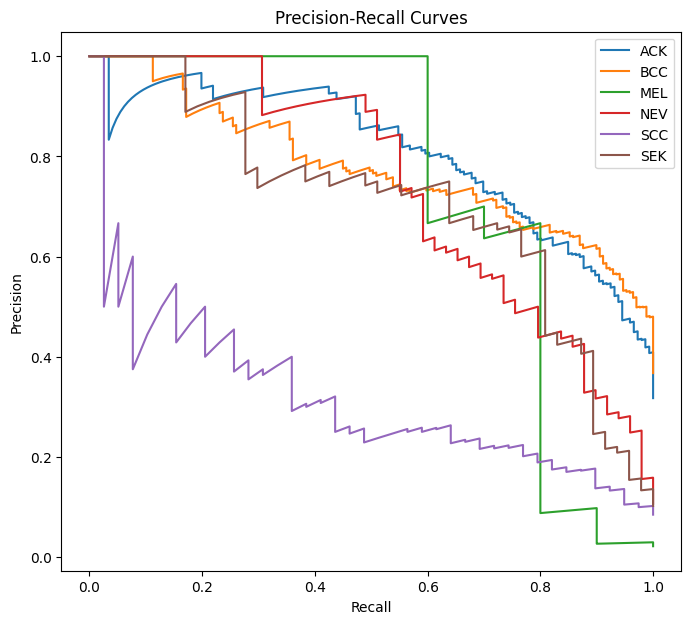

In [ ]:
plt.figure(figsize=(8,7))

for i in range(len(class_names)):

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=class_names[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

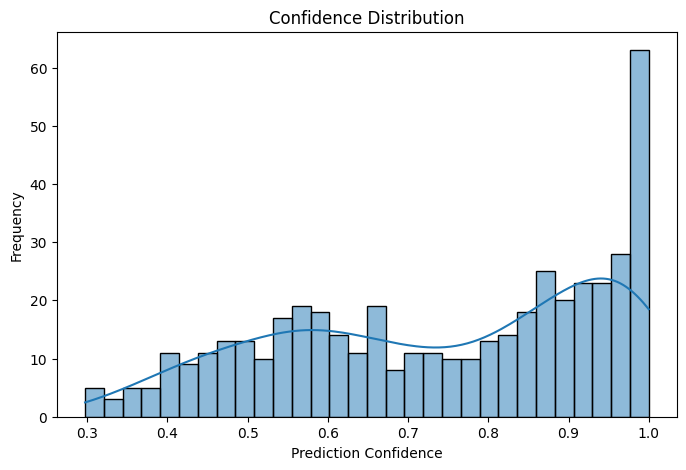

In [ ]:
confidence_scores = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence_scores,
    bins=30,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")
plt.show()